In [1]:
"""
Customer Churn Prediction Using Decision Tree Algorithm
University Machine Learning Assignment
Author: [Your Name]
Date: 2024
"""

# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine Learning imports
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                            f1_score, confusion_matrix, classification_report)
from sklearn.preprocessing import LabelEncoder

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# Load dataset
file_path = '../dataset/customer_churn.csv'
df = pd.read_csv(file_path)

# Display basic information
print("="*50)
print("DATASET INFORMATION")
print("="*50)
print(f"Dataset shape: {df.shape}")
print(f"\nColumn names: {df.columns.tolist()}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nFirst 5 rows:")
print(df.head())

# Basic statistics
print(f"\nDescriptive Statistics:")
print(df.describe())

# Check for missing values
print(f"\nMissing values:\n{df.isnull().sum()}")

DATASET INFORMATION
Dataset shape: (7043, 21)

Column names: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


In [3]:
# Remove customerID column
if 'customerID' in df.columns:
    df.drop('customerID', axis=1, inplace=True)
    print("customerID column removed")

# Check for empty strings in TotalCharges
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna()
print(f"Dataset shape after removing NaN values: {df.shape}")

# Encode categorical variables
categorical_columns = df.select_dtypes(include=['object']).columns.tolist()
print(f"\nCategorical columns to encode: {categorical_columns}")

# Encode target variable separately
le = LabelEncoder()
df['Churn'] = le.fit_transform(df['Churn'])
print(f"Churn mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Encode other categorical columns
label_encoders = {}
for col in categorical_columns:
    if col != 'Churn':
        le_temp = LabelEncoder()
        df[col] = le_temp.fit_transform(df[col])
        label_encoders[col] = le_temp
        print(f"Encoded {col}: {dict(zip(le_temp.classes_, le_temp.transform(le_temp.classes_)))}")

# Prepare features and target
X = df.drop('Churn', axis=1)
y = df['Churn']

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Target distribution:\n{y.value_counts()}")

customerID column removed
Dataset shape after removing NaN values: (7032, 20)

Categorical columns to encode: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']
Churn mapping: {'No': np.int64(0), 'Yes': np.int64(1)}
Encoded gender: {'Female': np.int64(0), 'Male': np.int64(1)}
Encoded Partner: {'No': np.int64(0), 'Yes': np.int64(1)}
Encoded Dependents: {'No': np.int64(0), 'Yes': np.int64(1)}
Encoded PhoneService: {'No': np.int64(0), 'Yes': np.int64(1)}
Encoded MultipleLines: {'No': np.int64(0), 'No phone service': np.int64(1), 'Yes': np.int64(2)}
Encoded InternetService: {'DSL': np.int64(0), 'Fiber optic': np.int64(1), 'No': np.int64(2)}
Encoded OnlineSecurity: {'No': np.int64(0), 'No internet service': np.int64(1), 'Yes': np.int64(2)}
Encoded OnlineBackup: {'No': np.int64(0), 'No internet se

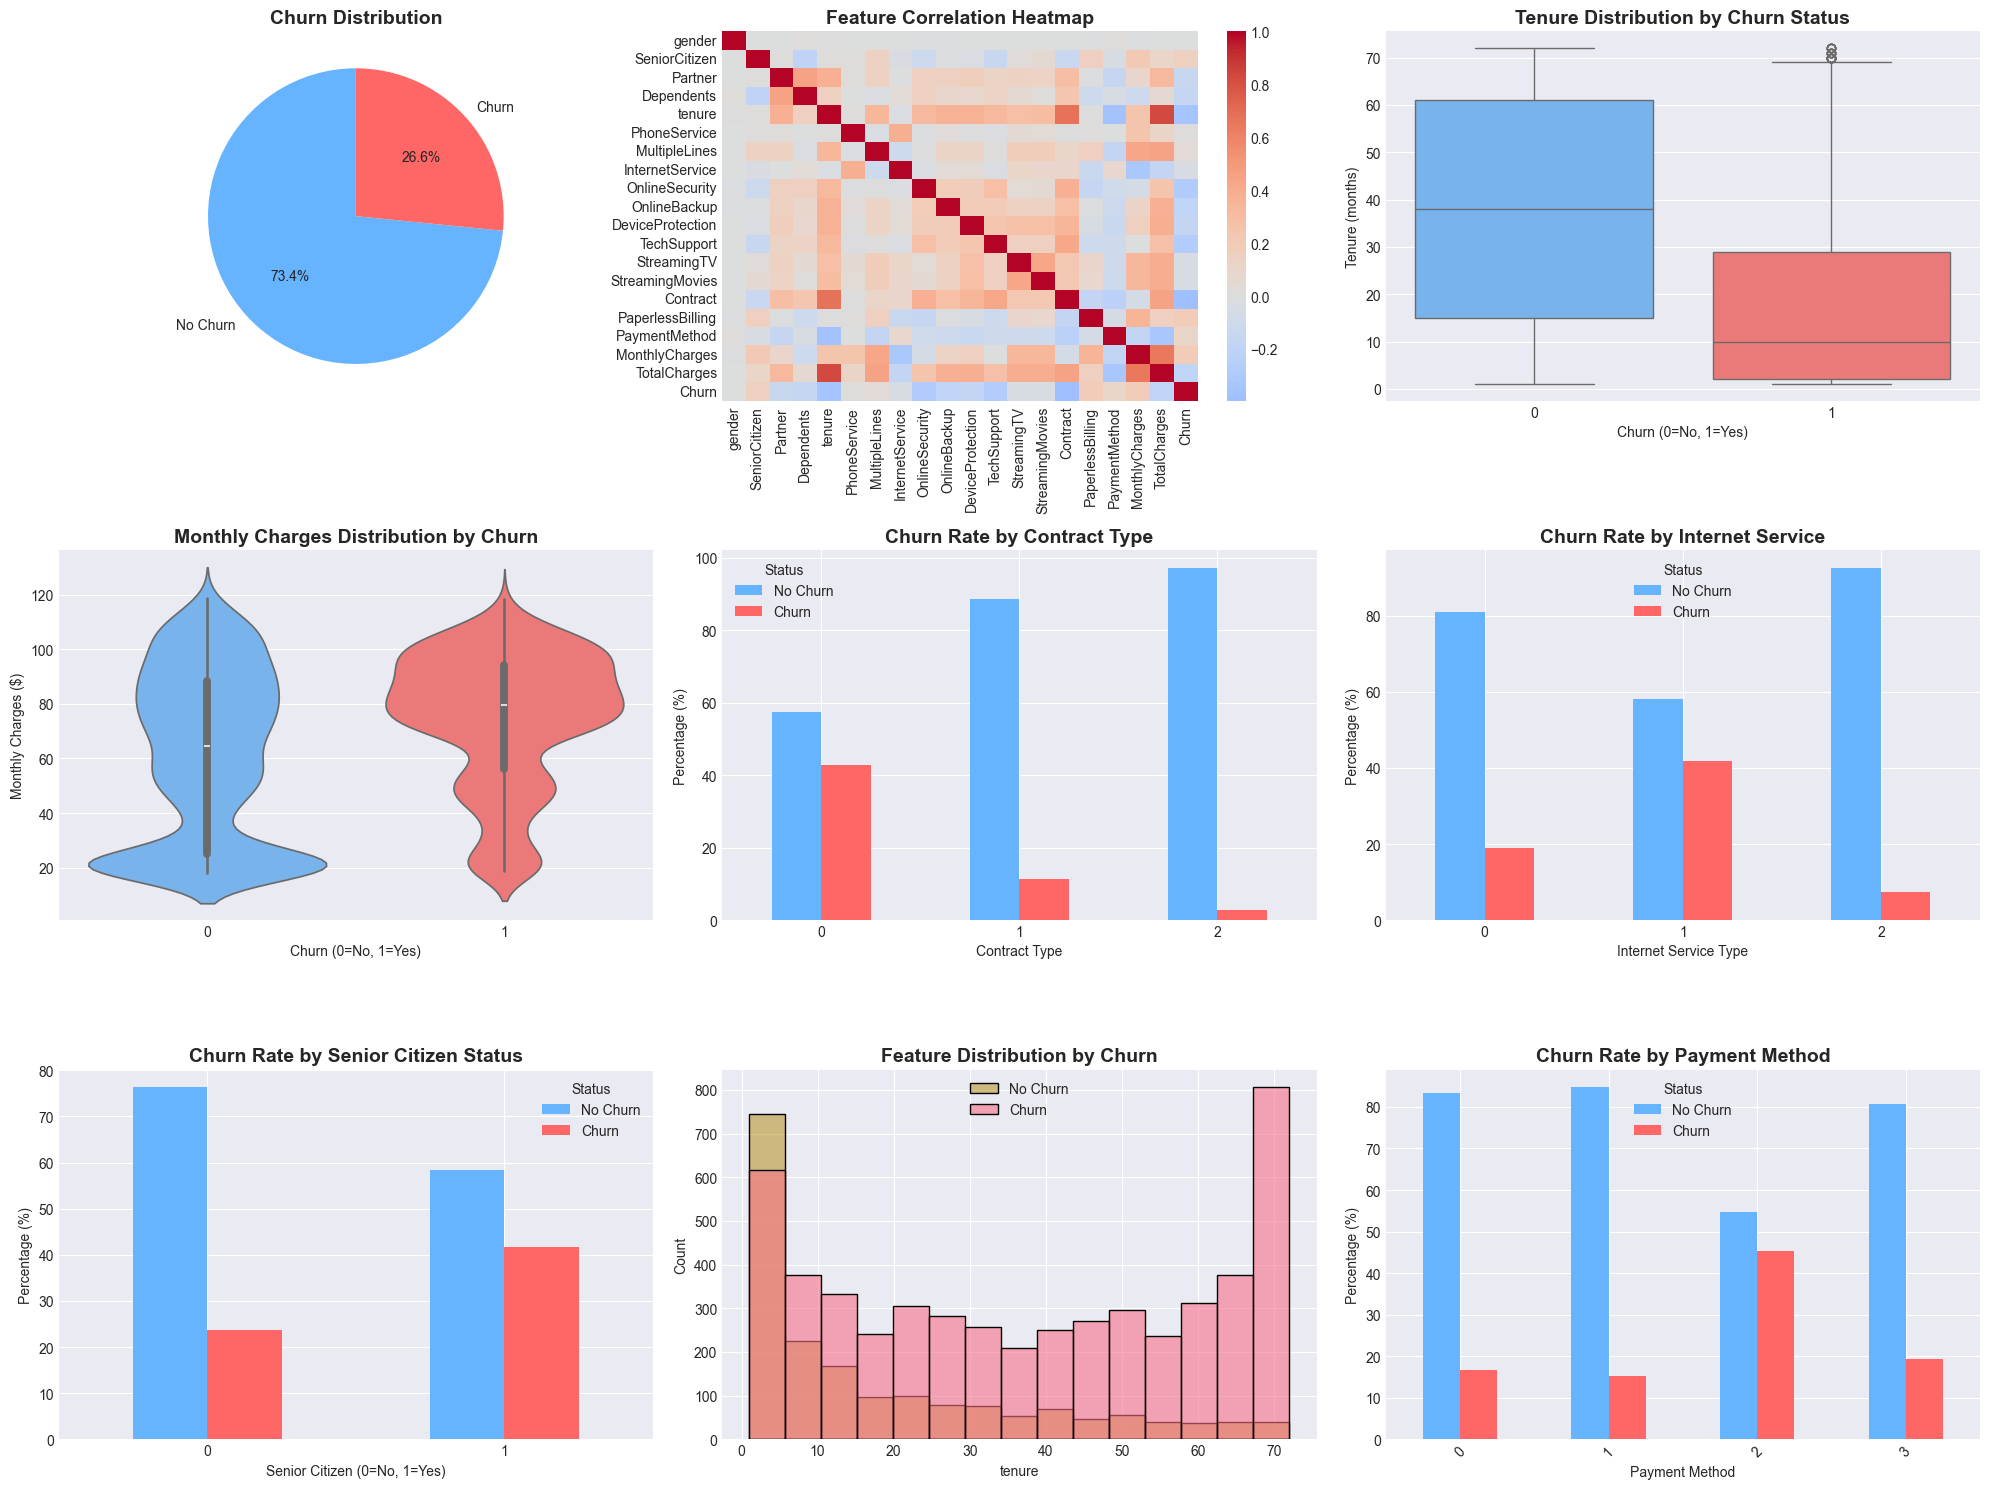

In [4]:
# Create a figure with subplots
fig = plt.figure(figsize=(20, 15))

# 1. Churn Distribution
plt.subplot(3, 3, 1)
churn_counts = y.value_counts()
plt.pie(churn_counts, labels=['No Churn', 'Churn'], autopct='%1.1f%%', 
        colors=['#66b3ff', '#ff6666'], startangle=90)
plt.title('Churn Distribution', fontsize=14, fontweight='bold')

# 2. Correlation Heatmap
plt.subplot(3, 3, 2)
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')

# 3. Tenure vs Churn
plt.subplot(3, 3, 3)
sns.boxplot(x='Churn', y='tenure', data=df, palette=['#66b3ff', '#ff6666'])
plt.title('Tenure Distribution by Churn Status', fontsize=14, fontweight='bold')
plt.xlabel('Churn (0=No, 1=Yes)')
plt.ylabel('Tenure (months)')

# 4. Monthly Charges vs Churn
plt.subplot(3, 3, 4)
sns.violinplot(x='Churn', y='MonthlyCharges', data=df, palette=['#66b3ff', '#ff6666'])
plt.title('Monthly Charges Distribution by Churn', fontsize=14, fontweight='bold')
plt.xlabel('Churn (0=No, 1=Yes)')
plt.ylabel('Monthly Charges ($)')

# 5. Contract Type vs Churn
plt.subplot(3, 3, 5)
contract_churn = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100
contract_churn.plot(kind='bar', color=['#66b3ff', '#ff6666'], ax=plt.gca())
plt.title('Churn Rate by Contract Type', fontsize=14, fontweight='bold')
plt.xlabel('Contract Type')
plt.ylabel('Percentage (%)')
plt.legend(['No Churn', 'Churn'], title='Status')
plt.xticks(rotation=0)

# 6. Internet Service vs Churn
plt.subplot(3, 3, 6)
internet_churn = pd.crosstab(df['InternetService'], df['Churn'], normalize='index') * 100
internet_churn.plot(kind='bar', color=['#66b3ff', '#ff6666'], ax=plt.gca())
plt.title('Churn Rate by Internet Service', fontsize=14, fontweight='bold')
plt.xlabel('Internet Service Type')
plt.ylabel('Percentage (%)')
plt.legend(['No Churn', 'Churn'], title='Status')
plt.xticks(rotation=0)

# 7. Senior Citizen vs Churn
plt.subplot(3, 3, 7)
senior_churn = pd.crosstab(df['SeniorCitizen'], df['Churn'], normalize='index') * 100
senior_churn.plot(kind='bar', color=['#66b3ff', '#ff6666'], ax=plt.gca())
plt.title('Churn Rate by Senior Citizen Status', fontsize=14, fontweight='bold')
plt.xlabel('Senior Citizen (0=No, 1=Yes)')
plt.ylabel('Percentage (%)')
plt.legend(['No Churn', 'Churn'], title='Status')
plt.xticks(rotation=0)

# 8. Feature Distribution (Top 5 numerical features)
plt.subplot(3, 3, 8)
numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']
for feature in numerical_features:
    if feature in X.columns:
        sns.histplot(data=df, x=feature, hue='Churn', alpha=0.6, ax=plt.gca())
        break
plt.title('Feature Distribution by Churn', fontsize=14, fontweight='bold')
plt.legend(['No Churn', 'Churn'])

# 9. Payment Method vs Churn
plt.subplot(3, 3, 9)
payment_churn = pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index') * 100
payment_churn.plot(kind='bar', color=['#66b3ff', '#ff6666'], ax=plt.gca())
plt.title('Churn Rate by Payment Method', fontsize=14, fontweight='bold')
plt.xlabel('Payment Method')
plt.ylabel('Percentage (%)')
plt.legend(['No Churn', 'Churn'], title='Status')
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('../results/eda_visualizations.png', dpi=300, bbox_inches='tight')
plt.show()

In [5]:
# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("="*50)
print("DATASET SPLIT INFORMATION")
print("="*50)
print(f"Training set size: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Testing set size: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nTraining set churn distribution:\n{y_train.value_counts()}")
print(f"\nTesting set churn distribution:\n{y_test.value_counts()}")

DATASET SPLIT INFORMATION
Training set size: 5625 samples (80.0%)
Testing set size: 1407 samples (20.0%)

Training set churn distribution:
Churn
0    4130
1    1495
Name: count, dtype: int64

Testing set churn distribution:
Churn
0    1033
1     374
Name: count, dtype: int64


In [6]:
"""
DECISION TREE THEORETICAL BACKGROUND

Decision Tree is a supervised learning algorithm used for classification and regression.
It creates a tree-like model of decisions based on the features.

Key Concepts:

1. Root Node: The top-most node representing the entire dataset
2. Splitting: Process of dividing a node into sub-nodes
3. Internal Node: Nodes that have child nodes
4. Leaf Node: Final nodes that make predictions
5. Information Gain: Reduction in entropy after splitting
   IG = Entropy(parent) - Weighted Sum of Entropy(children)
6. Gini Index: Measure of impurity
   Gini = 1 - Σ(p_i)^2
7. Tree Depth: Maximum number of splits from root to leaf
8. Overfitting: When the model learns noise in training data
9. Pruning: Removing branches to reduce overfitting
"""

'\nDECISION TREE THEORETICAL BACKGROUND\n\nDecision Tree is a supervised learning algorithm used for classification and regression.\nIt creates a tree-like model of decisions based on the features.\n\nKey Concepts:\n\n1. Root Node: The top-most node representing the entire dataset\n2. Splitting: Process of dividing a node into sub-nodes\n3. Internal Node: Nodes that have child nodes\n4. Leaf Node: Final nodes that make predictions\n5. Information Gain: Reduction in entropy after splitting\n   IG = Entropy(parent) - Weighted Sum of Entropy(children)\n6. Gini Index: Measure of impurity\n   Gini = 1 - Σ(p_i)^2\n7. Tree Depth: Maximum number of splits from root to leaf\n8. Overfitting: When the model learns noise in training data\n9. Pruning: Removing branches to reduce overfitting\n'

In [7]:
# Initialize Decision Tree Classifier
dt_initial = DecisionTreeClassifier(random_state=42)

# Train the model
dt_initial.fit(X_train, y_train)

# Make predictions
y_pred_initial = dt_initial.predict(X_test)

# Evaluate initial model
print("="*50)
print("INITIAL DECISION TREE PERFORMANCE")
print("="*50)
print(f"Accuracy: {accuracy_score(y_test, y_pred_initial):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_initial):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_initial):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_initial):.4f}")

# Training accuracy to check overfitting
y_train_pred = dt_initial.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)
print(f"\nTraining Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {accuracy_score(y_test, y_pred_initial):.4f}")
print(f"Overfitting Gap: {train_accuracy - accuracy_score(y_test, y_pred_initial):.4f}")

# Tree depth and size
print(f"\nTree Depth: {dt_initial.tree_.max_depth}")
print(f"Number of Leaves: {dt_initial.tree_.n_leaves}")
print(f"Total Nodes: {dt_initial.tree_.node_count}")

INITIAL DECISION TREE PERFORMANCE
Accuracy: 0.7129
Precision: 0.4631
Recall: 0.5027
F1-Score: 0.4821

Training Accuracy: 0.9988
Testing Accuracy: 0.7129
Overfitting Gap: 0.2859

Tree Depth: 26
Number of Leaves: 1093
Total Nodes: 2185


In [8]:
# Define hyperparameter grid
param_grid = {
    'max_depth': [3, 5, 7, 10, 15],
    'min_samples_split': [2, 5, 10, 20],
    'criterion': ['gini', 'entropy'],
    'min_samples_leaf': [1, 2, 5, 10]
}

# Initialize Decision Tree
dt = DecisionTreeClassifier(random_state=42)

# Perform Grid Search with Cross Validation
print("Performing Grid Search with Cross Validation...")
grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

# Best parameters
print("\n" + "="*50)
print("BEST HYPERPARAMETERS")
print("="*50)
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Score: {grid_search.best_score_:.4f}")

# Best model
best_dt = grid_search.best_estimator_

Performing Grid Search with Cross Validation...
Fitting 5 folds for each of 160 candidates, totalling 800 fits

BEST HYPERPARAMETERS
Best Parameters: {'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 10, 'min_samples_split': 2}
Best Cross-Validation Score: 0.5663


In [9]:
# Train best model
best_dt.fit(X_train, y_train)

# Make predictions
y_pred = best_dt.predict(X_test)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("="*50)
print("FINAL DECISION TREE PERFORMANCE")
print("="*50)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

# Training accuracy to verify overfitting
y_train_pred = best_dt.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)
print(f"\nTraining Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {accuracy:.4f}")
print(f"Overfitting Gap: {train_accuracy - accuracy:.4f}")

# Tree depth and size
print(f"\nFinal Tree Depth: {best_dt.tree_.max_depth}")
print(f"Number of Leaves: {best_dt.tree_.n_leaves}")

# Detailed classification report
print("\n" + "="*50)
print("CLASSIFICATION REPORT")
print("="*50)
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

FINAL DECISION TREE PERFORMANCE
Accuracy:  0.7783
Precision: 0.5957
Recall:    0.5160
F1-Score:  0.5530

Training Accuracy: 0.8178
Testing Accuracy: 0.7783
Overfitting Gap: 0.0395

Final Tree Depth: 7
Number of Leaves: 87

CLASSIFICATION REPORT
              precision    recall  f1-score   support

    No Churn       0.83      0.87      0.85      1033
       Churn       0.60      0.52      0.55       374

    accuracy                           0.78      1407
   macro avg       0.71      0.69      0.70      1407
weighted avg       0.77      0.78      0.77      1407



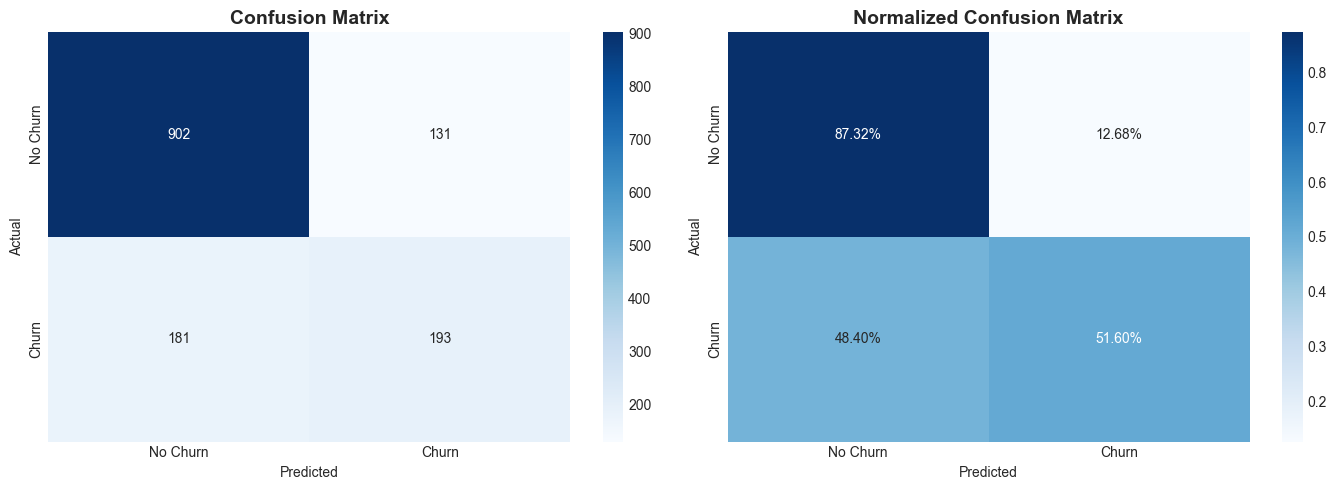

Confusion Matrix Breakdown:
True Negatives (Correctly predicted No Churn): 902
False Positives (Incorrectly predicted Churn): 131
False Negatives (Missed Churn predictions): 181
True Positives (Correctly predicted Churn): 193


In [10]:
# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_xticklabels(['No Churn', 'Churn'])
axes[0].set_yticklabels(['No Churn', 'Churn'])

# Normalized heatmap
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', ax=axes[1])
axes[1].set_title('Normalized Confusion Matrix', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_xticklabels(['No Churn', 'Churn'])
axes[1].set_yticklabels(['No Churn', 'Churn'])

plt.tight_layout()
plt.savefig('../results/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Calculate metrics from confusion matrix
tn, fp, fn, tp = cm.ravel()
print("Confusion Matrix Breakdown:")
print(f"True Negatives (Correctly predicted No Churn): {tn}")
print(f"False Positives (Incorrectly predicted Churn): {fp}")
print(f"False Negatives (Missed Churn predictions): {fn}")
print(f"True Positives (Correctly predicted Churn): {tp}")

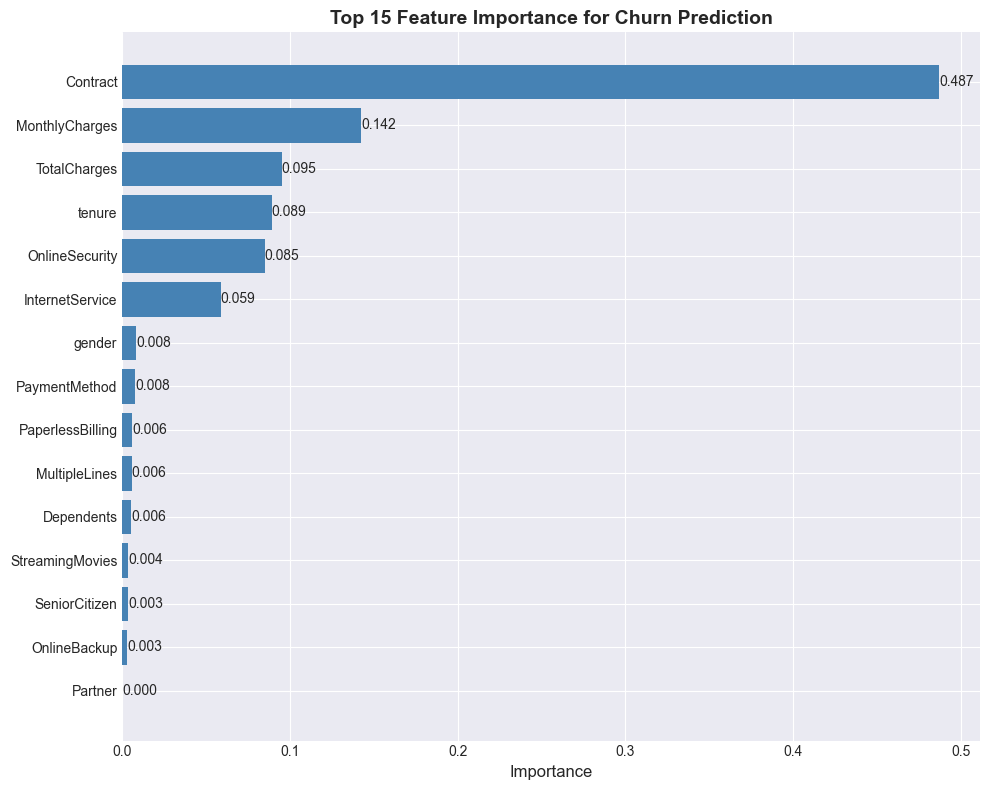

TOP 10 MOST IMPORTANT FEATURES
         feature  importance
        Contract    0.486976
  MonthlyCharges    0.142266
    TotalCharges    0.095077
          tenure    0.089079
  OnlineSecurity    0.084914
 InternetService    0.058625
          gender    0.008354
   PaymentMethod    0.007559
PaperlessBilling    0.006007
   MultipleLines    0.005609


In [11]:
# Get feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': best_dt.feature_importances_
}).sort_values('importance', ascending=False)

# Plot feature importance
fig, ax = plt.subplots(figsize=(10, 8))

bars = ax.barh(feature_importance['feature'][:15], 
               feature_importance['importance'][:15], 
               color='steelblue')

ax.set_xlabel('Importance', fontsize=12)
ax.set_title('Top 15 Feature Importance for Churn Prediction', fontsize=14, fontweight='bold')
ax.invert_yaxis()

# Add value labels
for i, (bar, val) in enumerate(zip(bars, feature_importance['importance'][:15])):
    ax.text(val, bar.get_y() + bar.get_height()/2, f'{val:.3f}', 
            va='center', ha='left', fontsize=10)

plt.tight_layout()
plt.savefig('../results/feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

# Display top features
print("="*50)
print("TOP 10 MOST IMPORTANT FEATURES")
print("="*50)
print(feature_importance.head(10).to_string(index=False))

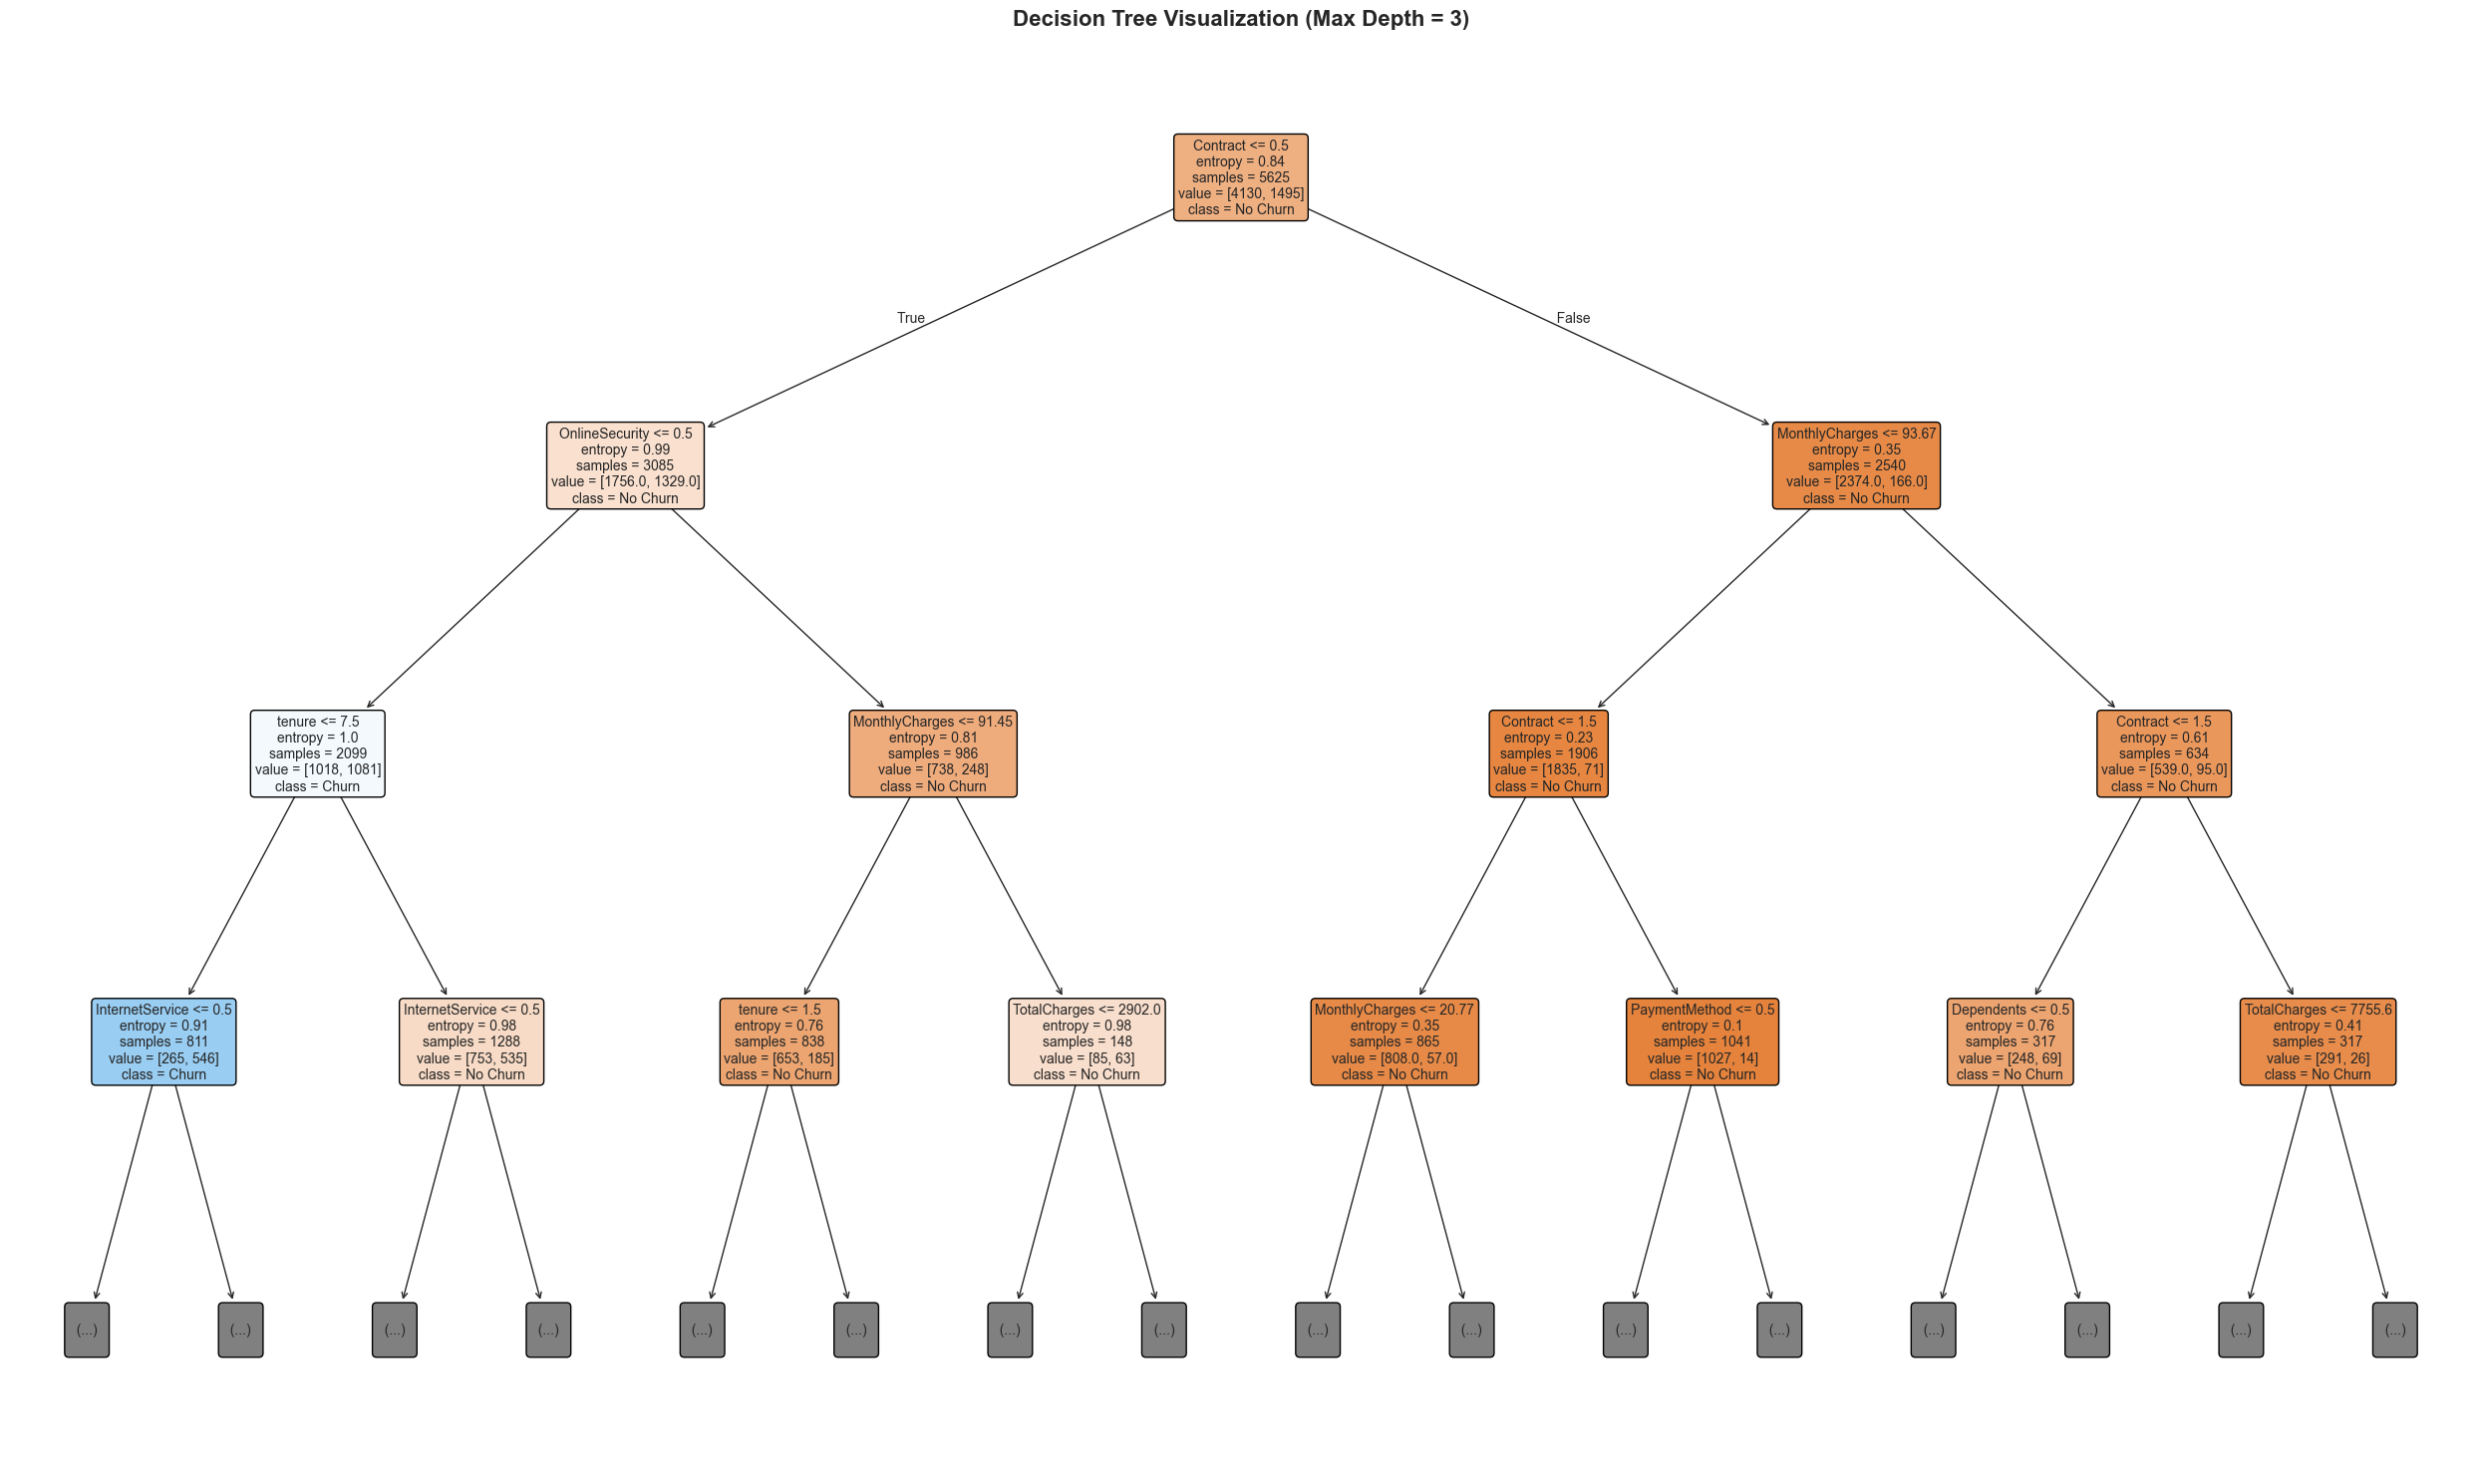

Model saved to: ../models/decision_tree_churn_model.pkl


In [12]:
# Plot the decision tree
plt.figure(figsize=(25, 15))

# Limit tree depth for better visualization
plot_tree(best_dt, 
          max_depth=3,
          feature_names=X.columns,
          class_names=['No Churn', 'Churn'],
          filled=True,
          rounded=True,
          fontsize=10,
          precision=2)

plt.title('Decision Tree Visualization (Max Depth = 3)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/decision_tree_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

# Save model
import joblib
joblib.dump(best_dt, '../models/decision_tree_churn_model.pkl')
print("Model saved to: ../models/decision_tree_churn_model.pkl")

In [13]:
"""
DECISION TREE MODEL ANALYSIS & BUSINESS INSIGHTS

Model Performance Summary:
- Accuracy: {accuracy:.2%} of predictions are correct
- Precision: {precision:.2%} of churn predictions are correct
- Recall: {recall:.2%} of actual churn cases are detected
- F1-Score: {f1:.2%} harmonic mean of precision and recall

Key Business Insights from Feature Importance:

1. Tenure is the most important factor - customers with shorter tenure are more likely to churn
2. Contract type significantly impacts churn - month-to-month contracts have highest churn
3. Monthly charges affect churn - higher charges correlate with increased churn
4. Internet service type influences retention - fiber optic users show different patterns
5. Payment method matters - electronic check users churn more frequently

Recommendations:
1. Focus retention efforts on new customers (first 12 months)
2. Encourage customers to switch to long-term contracts
3. Review pricing strategy for high monthly charges
4. Improve service quality for fiber optic customers
5. Offer incentives to switch from electronic check to auto-pay
"""

print("Model Analysis Complete!")
print(f"Final Model Performance: F1-Score = {f1:.4f}")
print(f"Tree Depth: {best_dt.tree_.max_depth}")
print(f"Number of Leaves: {best_dt.tree_.n_leaves}")

Model Analysis Complete!
Final Model Performance: F1-Score = 0.5530
Tree Depth: 7
Number of Leaves: 87


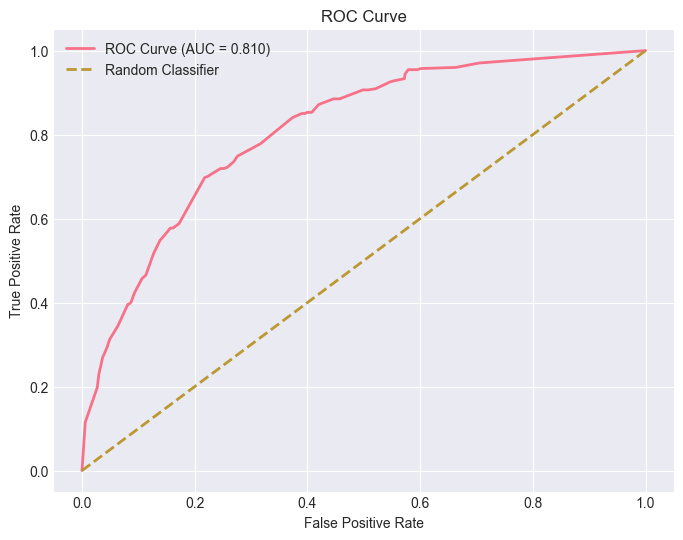

AUC Score: 0.8101


In [14]:
# ROC Curve and AUC Score
from sklearn.metrics import roc_curve, roc_auc_score

# Get prediction probabilities
y_pred_proba = best_dt.predict_proba(X_test)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, lw=2, label=f'ROC Curve (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], lw=2, linestyle='--', label='Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)

plt.savefig('../results/roc_curve.png')
plt.show()

print(f"AUC Score: {auc_score:.4f}")

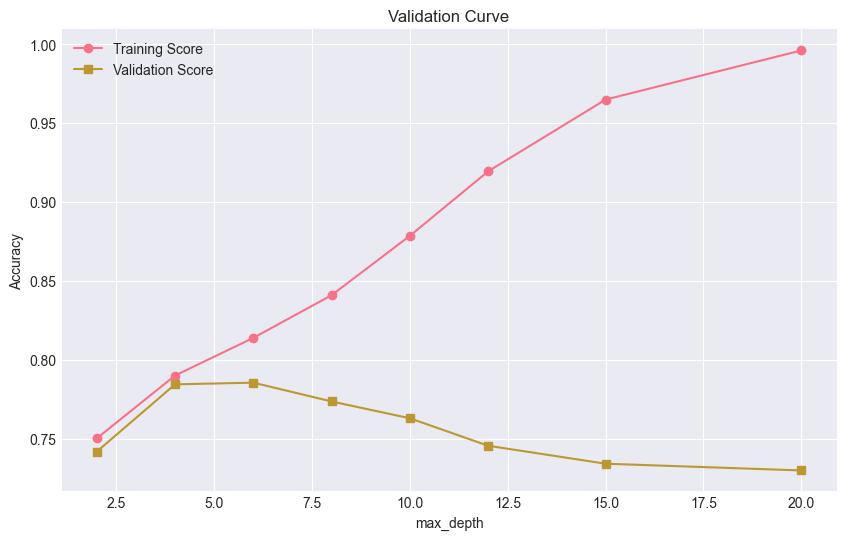

In [15]:
from sklearn.model_selection import validation_curve

param_range = [2, 4, 6, 8, 10, 12, 15, 20]

train_scores, test_scores = validation_curve(
    DecisionTreeClassifier(random_state=42),
    X_train, y_train,
    param_name='max_depth',
    param_range=param_range,
    cv=5,
    scoring='accuracy'
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(param_range, train_mean, marker='o', label='Training Score')
plt.plot(param_range, test_mean, marker='s', label='Validation Score')

plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Validation Curve')
plt.legend()
plt.grid(True)

plt.savefig('../results/validation_curve.png')
plt.show()

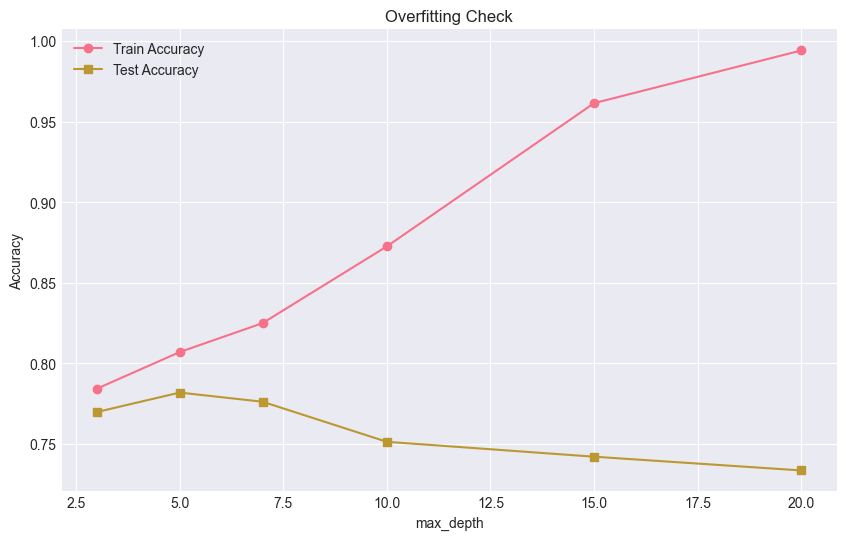

In [16]:
depths = [3, 5, 7, 10, 15, 20]
train_acc = []
test_acc = []

for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train, y_train)
    
    train_acc.append(accuracy_score(y_train, model.predict(X_train)))
    test_acc.append(accuracy_score(y_test, model.predict(X_test)))

plt.figure(figsize=(10, 6))
plt.plot(depths, train_acc, marker='o', label='Train Accuracy')
plt.plot(depths, test_acc, marker='s', label='Test Accuracy')

plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Overfitting Check')
plt.legend()
plt.grid(True)

plt.savefig('../results/depth_analysis.png')
plt.show()